In [55]:
import pandas as pd
import numpy as np

In [56]:
df = pd.read_csv('/Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/mental_dataset.csv')

In [57]:
df.shape

(352, 82)

In [58]:
df.columns

Index(['*Are you self-employed?*',
       'How many employees does your company or organization have?',
       'Is your employer primarily a tech company/organization?',
       'Is your primary role within your company related to tech/IT?',
       'Does your employer provide mental health benefits as part of healthcare coverage?',
       'Do you know the options for mental health care available under your employer-provided health coverage?',
       'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?',
       'Does your employer offer resources to learn more about mental health disorders and options for seeking help?',
       'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
       'If a mental health issue prompted you to request a medical leave from work, how easy or difficult would it be to ask for that lea

Identify columns that are free text  

In [59]:
df.nunique().sort_values(ascending=False)

Why or why not?.1                                                                                                                                                                                                                   281
Why or why not?                                                                                                                                                                                                                     271
Briefly describe what you think the industry as a whole and/or employers could do to improve mental health support for employees.                                                                                                   251
Describe the conversation with coworkers you had about your mental health including their reactions.                                                                                                                                119
Describe the conversation your coworker had with you about their mental 

In [60]:
pd.set_option('display.max_rows', None)
df.nunique().sort_values(ascending=False)
print(df.nunique().sort_values(ascending=False).to_string())

Why or why not?.1                                                                                                                                                                                                                   281
Why or why not?                                                                                                                                                                                                                     271
Briefly describe what you think the industry as a whole and/or employers could do to improve mental health support for employees.                                                                                                   251
Describe the conversation with coworkers you had about your mental health including their reactions.                                                                                                                                119
Describe the conversation your coworker had with you about their mental 

In [61]:
df.shape

(352, 82)

Only keep the things we need

In [62]:
cols_to_keep = [
    'Have you ever sought treatment for a mental health disorder from a mental health professional?',
    'Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?',
    'Overall, how well do you think the tech industry supports employees with mental health issues?',
    'What is your age?',
    'What is your gender?',
    'What is your race?',
    'What country do you *live* in?',
    'Do you *currently* have a mental health disorder?',
    'Do you have a family history of mental illness?',
]

df = df[cols_to_keep]

In [63]:
df.shape

(352, 9)

Check duplicate and then drop them

In [64]:
df[df.duplicated(keep=False)]


,Have you ever sought treatment for a mental health disorder from a mental health professional?,Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?,"Overall, how well do you think the tech industry supports employees with mental health issues?",What is your age?,What is your gender?,What is your race?,What country do you *live* in?,Do you *currently* have a mental health disorder?,Do you have a family history of mental illness?
147,True,Yes,3,42,Female,NaN,United Kingdom,Yes,I don't know
174,True,Maybe,2,38,Female,White,United States of America,Yes,Yes
300,True,Yes,3,42,Female,NaN,United Kingdom,Yes,I don't know
330,True,Maybe,2,38,Female,White,United States of America,Yes,Yes


In [65]:
df = df.drop_duplicates()

In [66]:
df.shape

(350, 9)

Checking for null values

In [67]:
print(df.isnull().sum())

Have you ever sought treatment for a mental health disorder from a mental health professional?      0
Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?        48
Overall, how well do you think the tech industry supports employees with mental health issues?      0
What is your age?                                                                                   0
What is your gender?                                                                                7
What is your race?                                                                                147
What country do you *live* in?                                                                      0
Do you *currently* have a mental health disorder?                                                   0
Do you have a family history of mental illness?                                                     0
dtype: int64


Drop entire 48 rows where it's empty at 'Would you ...' because it's a core variable and we'll end up having 'null' value in the chart if we dont   

In [68]:
df = df.dropna(subset=['Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?'])


In [69]:
df.shape

(302, 9)

Map gender data to only have male, female, and non binary

In [70]:
male = ['male', 'man', 'm', 'masculine', 'masculino', 'cis male', 'cishet male',
        'identify as male', 'make', 'let\'s keep it simple and say "male"']

female = ['female', 'woman', 'f', 'femmina', 'femile', 'cis woman', 'female (cis)']

nonbinary = ['non-binary', 'nonbinary', 'non binary', 'agender', 'genderfluid',
             'trans man', 'agender trans woman', 'trans non-binary/genderfluid',
             'non-binary and gender fluid', 'questioning']

def standardize_gender(value):
    if pd.isna(value):
        return np.nan

    v = str(value).strip().lower()

    if v.isdigit():
        return np.nan
    if v in nonbinary:
        return 'Non-binary'
    if v in male:
        return 'Male'
    if v in female:
        return 'Female'

    return np.nan

df['gender_clean'] = df['What is your gender?'].apply(standardize_gender)

In [71]:
# see the unique values
print(df['Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?'].unique())

# see how many unique values
print(df['Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?'].nunique())

# see each value and how many times it appears
# print(df['Have you ever sought treatment for a mental health disorder from a mental health professional?'].value_counts())

['Yes' 'Maybe' 'No']
3


In [72]:
# see the unique values
print(df['Overall, how well do you think the tech industry supports employees with mental health issues?'].unique())

# see how many unique values
print(df['Overall, how well do you think the tech industry supports employees with mental health issues?'].nunique())


[4 1 2 3 5]
5


In [73]:
# see the unique values
print(df['Have you ever sought treatment for a mental health disorder from a mental health professional?'].unique())

# see how many unique values
print(df['Have you ever sought treatment for a mental health disorder from a mental health professional?'].nunique())


[False  True]
2


In [74]:
print(df['What is your gender?'].unique())

['Male' 'male' 'm' 'female' 'Female' nan 'M' 'F' 'f'
 'Let\'s keep it simple and say "male"' 'Non-binary' 'Identify as male'
 'Male ' 'Woman' 'Non binary' 'Masculine' 'Cishet male' 'Nonbinary'
 'agender' 'Man' 'Questioning' 'Cis Male' 'cis woman'
 'Agender trans woman' 'femmina' '43' 'Trans man' 'masculino' 'Female '
 'Make' 'Trans non-binary/genderfluid' 'CIS Male'
 'Non-binary and gender fluid' 'Femile' 'Female (cis)']


In [75]:
print(df['gender_clean'].unique())

['Male' 'Female' nan 'Non-binary']


In [76]:
import matplotlib.pyplot as plt


--- Have you ever sought treatment for a mental health disorder from a mental health professional? x What is your age? ---
       False  True 
group              
<30       38     53
30-39     45     80
40-49     22     46
50+        6     11
Saved: /Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures/step3_treatment_age.png


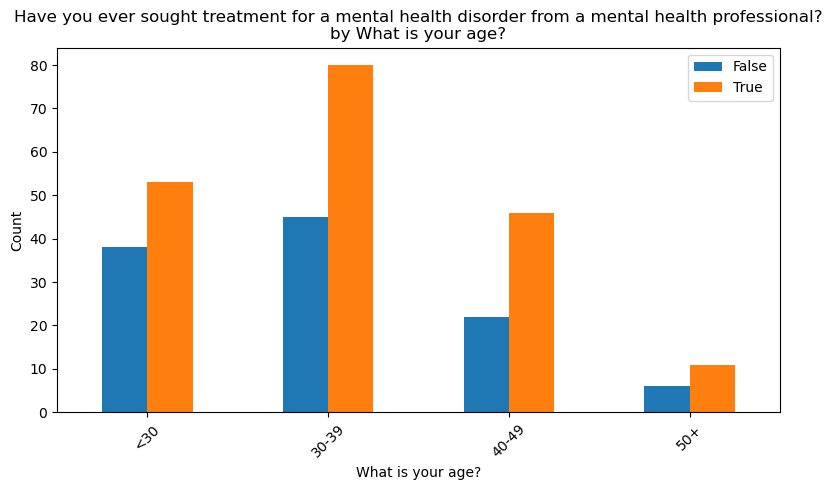


--- Have you ever sought treatment for a mental health disorder from a mental health professional? x gender_clean ---
              False  True 
gender_clean              
Female           22     62
Male             82    117
Non-binary        2      9
Saved: /Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures/step3_treatment_gender.png


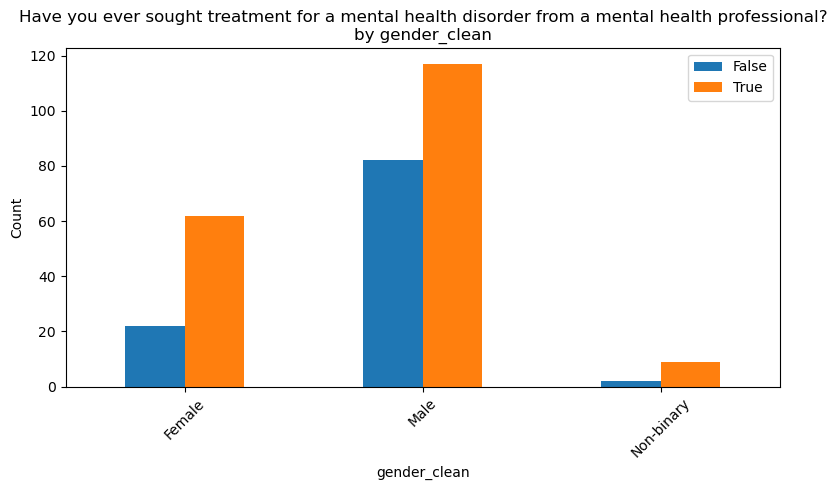


--- Have you ever sought treatment for a mental health disorder from a mental health professional? x What is your race? ---
                            False  True 
What is your race?                      
Asian                           6      3
Black or African American       0      2
Caucasian                       0      1
Hispanic                        1      0
I prefer not to answer          1      4
More than one of the above      2      6
White                          40    116
White Hispanic                  1      0
Saved: /Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures/step3_treatment_race.png


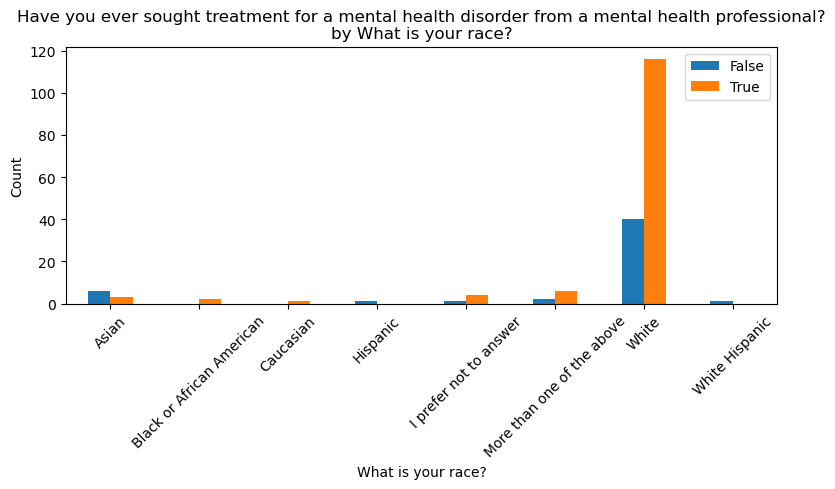


--- Would you feel comfortable discussing a mental health issue with your direct supervisor(s)? x What is your age? ---
       Maybe  No  Yes
group                
<30       23  36   32
30-39     41  33   51
40-49     21  19   28
50+        9   4    4
Saved: /Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures/step3_disclosure_age.png


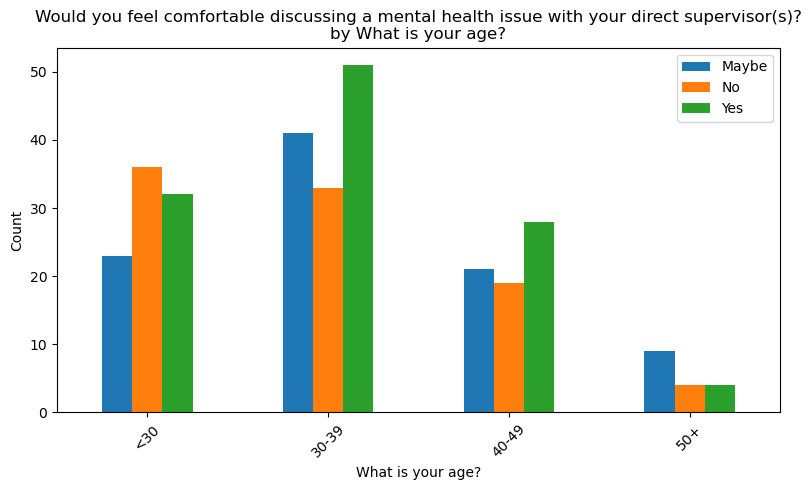


--- Would you feel comfortable discussing a mental health issue with your direct supervisor(s)? x gender_clean ---
              Maybe  No  Yes
gender_clean                
Female           24  35   25
Male             64  52   83
Non-binary        4   3    4
Saved: /Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures/step3_disclosure_gender.png


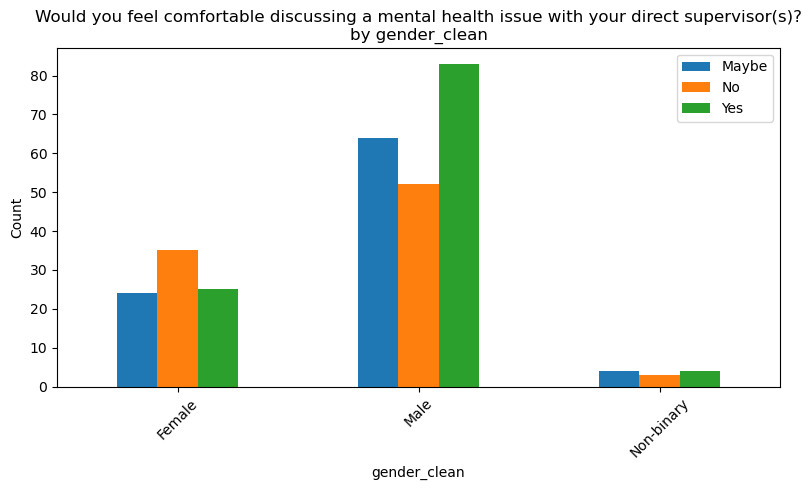


--- Would you feel comfortable discussing a mental health issue with your direct supervisor(s)? x What is your race? ---
                            Maybe  No  Yes
What is your race?                        
Asian                           4   3    2
Black or African American       2   0    0
Caucasian                       0   1    0
Hispanic                        0   1    0
I prefer not to answer          3   0    2
More than one of the above      1   6    1
White                          47  40   69
White Hispanic                  1   0    0
Saved: /Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures/step3_disclosure_race.png


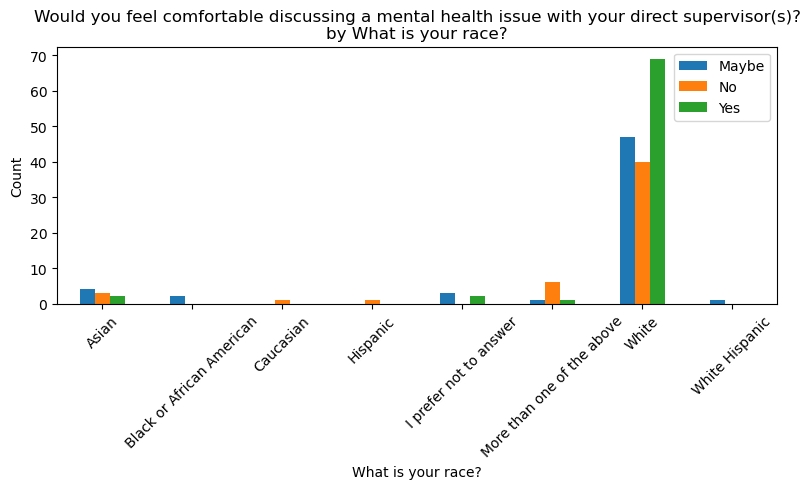


--- Overall, how well do you think the tech industry supports employees with mental health issues? x What is your age? ---
        1   2   3   4  5
group                   
<30     9  32  35  13  2
30-39  14  37  56  15  3
40-49  16  18  23  11  0
50+     4   7   5   1  0
Saved: /Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures/step3_support_age.png


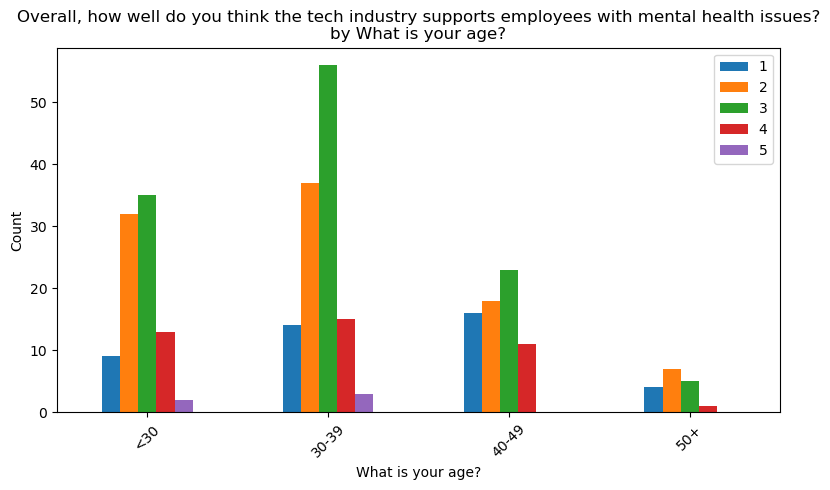


--- Overall, how well do you think the tech industry supports employees with mental health issues? x gender_clean ---
               1   2   3   4  5
gender_clean                   
Female        12  22  41   8  1
Male          29  64  70  33  3
Non-binary     2   3   6   0  0
Saved: /Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures/step3_support_gender.png


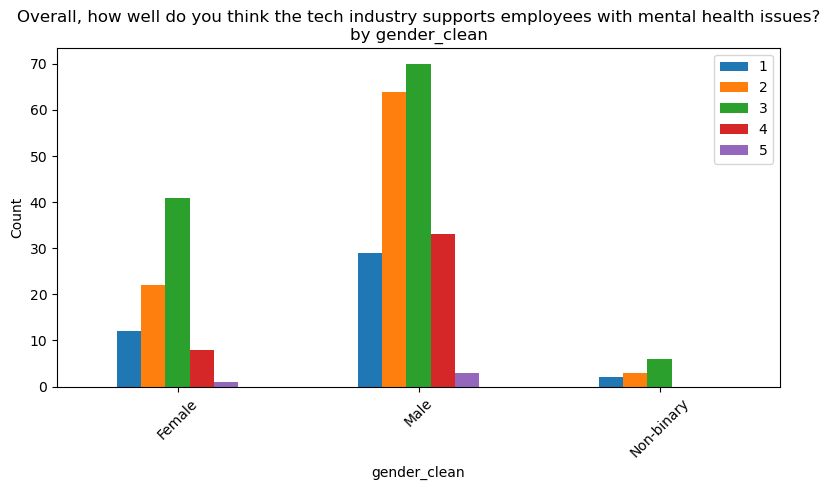


--- Overall, how well do you think the tech industry supports employees with mental health issues? x What is your race? ---
                             1   2   3   4  5
What is your race?                           
Asian                        2   1   3   3  0
Black or African American    1   0   1   0  0
Caucasian                    0   0   1   0  0
Hispanic                     0   1   0   0  0
I prefer not to answer       1   2   1   1  0
More than one of the above   3   2   2   1  0
White                       19  43  68  24  2
White Hispanic               0   0   1   0  0
Saved: /Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures/step3_support_race.png


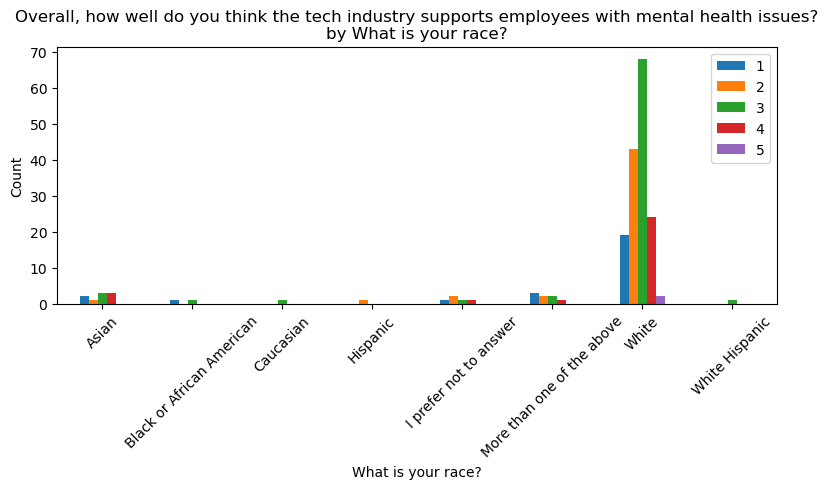

In [77]:
import os

figures_dir = '/Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures'
os.makedirs(figures_dir, exist_ok=True)

dep_short = {
    'Have you ever sought treatment for a mental health disorder from a mental health professional?': 'treatment',
    'Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?': 'disclosure',
    'Overall, how well do you think the tech industry supports employees with mental health issues?': 'support',
}

ind_short = {
    'What is your age?': 'age',
    'gender_clean': 'gender',
    'What is your race?': 'race',
}

dependent_vars = [
    'Have you ever sought treatment for a mental health disorder from a mental health professional?',
    'Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?',
    'Overall, how well do you think the tech industry supports employees with mental health issues?',
]

independent_vars = [
    'What is your age?',
    'gender_clean',
    'What is your race?',
]

for dep in dependent_vars:
    for ind in independent_vars:
        temp = df[[ind, dep]].dropna().copy()
        if ind == 'What is your age?':
            temp['group'] = pd.cut(
                temp[ind],
                bins=[0, 29, 39, 49, 100],
                labels=['<30', '30-39', '40-49', '50+']
            )
            x_col = 'group'
        else:
            x_col = ind
        # frequency table
        freq_table = pd.crosstab(temp[x_col], temp[dep])
        freq_table.columns.name = None  # removes long question from legend title
        print(f"\n--- {dep} x {ind} ---")
        print(freq_table)
        # bar chart using matplotlib only
        freq_table.plot(kind='bar', figsize=(8, 5), legend=True)
        plt.title(f'{dep}\nby {ind}')
        plt.xlabel(ind)
        plt.ylabel('Count')
        plt.legend(title=None)  # legend shows only False/True, Yes/Maybe/No, etc.
        plt.xticks(rotation=45)
        plt.tight_layout()

        filename = f"step3_{dep_short[dep]}_{ind_short[ind]}.png"
        save_path = os.path.join(figures_dir, filename)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")

        plt.show()
        plt.close()

## Step 4: Graph manipulation (Gender × Supervisor disclosure)

**Independent variable:** `gender_clean` (Sex — Title VII)  
**Dependent variable:** comfort discussing mental health with supervisor (Yes / Maybe / No)

Frequency table (Male & Female only):
              Maybe  No  Yes
gender_clean                
Female           24  35   25
Male             64  52   83

Row percentages:
              Maybe    No   Yes
gender_clean                   
Female         28.6  41.7  29.8
Male           32.2  26.1  41.7

Saved fair graph: /Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures/step4_fair_disclosure_gender.png


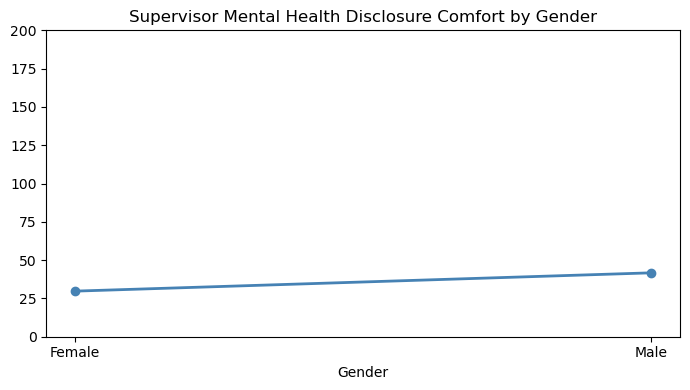

Saved bias graph: /Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures/step4_bias_disclosure_gender.png


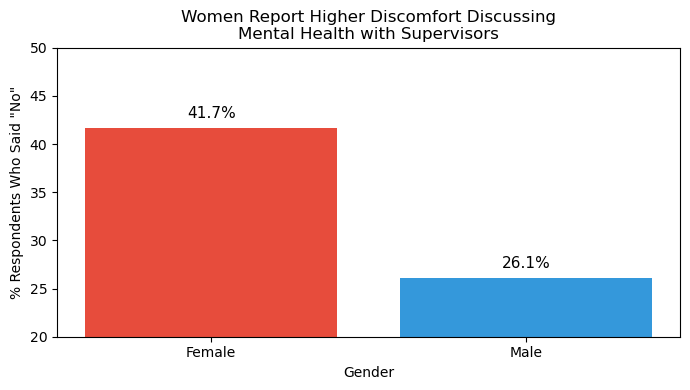

In [78]:
# Step 4 — Gender x supervisor disclosure comfort
import os

figures_dir = '/Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures'
os.makedirs(figures_dir, exist_ok=True)

disclosure_col = 'Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?'

step4 = df[['gender_clean', disclosure_col]].dropna().copy()
step4 = step4[step4['gender_clean'].isin(['Male', 'Female'])]

# Crosstab for reference
freq = pd.crosstab(step4['gender_clean'], step4[disclosure_col])
freq.columns.name = None
print("Frequency table (Male & Female only):")
print(freq)

# Percentages used for manipulation
pct = freq.div(freq.sum(axis=1), axis=0) * 100
print("\nRow percentages:")
print(pct.round(1))

# --- FAIR GRAPH ---
# Hypothesis: disclosure comfort is similar across genders
# Manipulations: line chart; show only % "Yes"; inflated 0-200 y-axis flattens the line; no y-axis label
fair_pct = pct['Yes']
genders = fair_pct.index

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(genders, fair_pct.values, marker='o', linewidth=2, color='steelblue')
ax.set_ylim(0, 200)  # larger max than 0-100 — same 12-pt gap looks even flatter
ax.set_title('Supervisor Mental Health Disclosure Comfort by Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('')  # no y-axis label hides that these are percentages
ax.set_xticks(range(len(genders)))
ax.set_xticklabels(genders)
plt.tight_layout()
fair_path = os.path.join(figures_dir, 'step4_fair_disclosure_gender.png')
plt.savefig(fair_path, dpi=150, bbox_inches='tight')
print(f"\nSaved fair graph: {fair_path}")
plt.show()
plt.close()

# --- BIAS GRAPH ---
# Hypothesis: women are less comfortable discussing mental health with supervisors
# Manipulations: bar chart of % "No"; y-axis starts at 20 (truncated) to exaggerate gap; emphatic title
bias_pct = pct['No']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(bias_pct.index, bias_pct.values, color=['#e74c3c', '#3498db'])
ax.set_ylim(20, 50)  # baseline at 20% — bars look ~3.5x taller for Female vs Male
ax.set_title('Women Report Higher Discomfort Discussing\nMental Health with Supervisors')
ax.set_xlabel('Gender')
ax.set_ylabel('% Respondents Who Said "No"')
for bar, value in zip(bars, bias_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{value:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
bias_path = os.path.join(figures_dir, 'step4_bias_disclosure_gender.png')
plt.savefig(bias_path, dpi=150, bbox_inches='tight')
print(f"Saved bias graph: {bias_path}")
plt.show()
plt.close()

Step 5

In [79]:
step4.head()

,gender_clean,Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?
0,Male,Yes
1,Male,Maybe
2,Male,No
3,Male,Yes
4,Male,No


In [80]:
# Map gender to 0/1 — Female=0, Male=1 and create a new column  
gender_map = {'Female': 0, 'Male': 1}
step4['gender_num'] = step4['gender_clean'].map(gender_map)

step4.head(10)


,gender_clean,Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?,gender_num
0,Male,Yes,1
1,Male,Maybe,1
2,Male,No,1
3,Male,Yes,1
4,Male,No,1
5,Female,No,0
6,Female,Maybe,0
9,Male,Yes,1
10,Male,Yes,1
12,Male,Yes,1


In [81]:
# Get Mean, Median, Mode

mean = step4['gender_num'].mean()    # proportion Male (since Male=1)
median = step4['gender_num'].median()  # 0 or 1 — middle value
mode = step4['gender_num'].mode()[0] # most common — likely 1 (Male)

print(mean, median, mode)

0.7031802120141343 1.0 1


In [82]:
reduced_step4 = step4.sample(frac=0.5, random_state=42)

reduced_mean = reduced_step4['gender_num'].mean()    # proportion Male (since Male=1)
reduced_median = reduced_step4['gender_num'].median()  # 0 or 1 — middle value
reduced_mode = reduced_step4['gender_num'].mode()[0] # most common — likely 1 (Male)

print(reduced_mean, reduced_median, reduced_mode)


0.676056338028169 1.0 1


Step 6


--- Would you feel comfortable discussing a mental health issue with your direct supervisor(s)? x gender_clean ---
              Maybe  No  Yes
gender_clean                
Female            9  22   15
Male             28  33   35
Saved: /Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures/step6_disclosure_gender.png


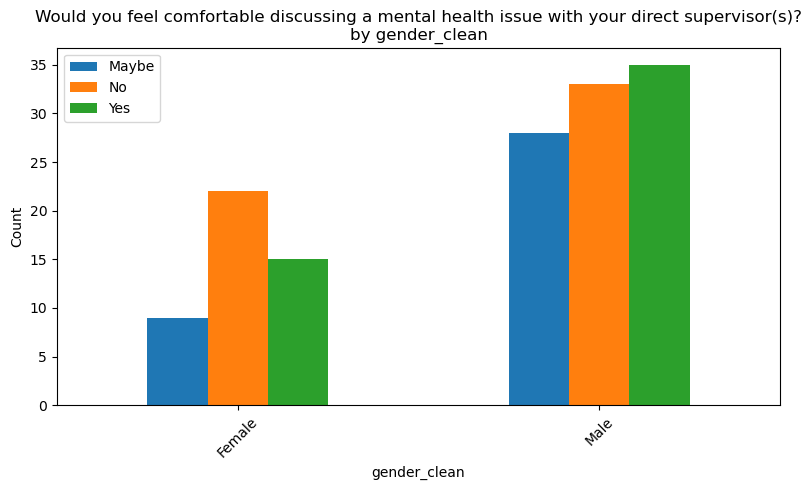

In [83]:
import os

figures_dir = '/Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Project_2/figures'
os.makedirs(figures_dir, exist_ok=True)

dep_short = {
    'Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?': 'disclosure',
}

ind_short = {
    'gender_clean': 'gender',
}

dependent_vars = [
    'Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?',
]

independent_vars = [
    'gender_clean',
]

for dep in dependent_vars:
    for ind in independent_vars:
        temp = reduced_step4[[ind, dep]].dropna().copy()
        if ind == 'What is your age?':
            temp['group'] = pd.cut(
                temp[ind],
                bins=[0, 29, 39, 49, 100],
                labels=['<30', '30-39', '40-49', '50+']
            )
            x_col = 'group'
        else:
            x_col = ind
        # frequency table
        freq_table = pd.crosstab(temp[x_col], temp[dep])
        freq_table.columns.name = None  # removes long question from legend title
        print(f"\n--- {dep} x {ind} ---")
        print(freq_table)
        # bar chart using matplotlib only
        freq_table.plot(kind='bar', figsize=(8, 5), legend=True)
        plt.title(f'{dep}\nby {ind}')
        plt.xlabel(ind)
        plt.ylabel('Count')
        plt.legend(title=None)  # legend shows only False/True, Yes/Maybe/No, etc.
        plt.xticks(rotation=45)
        plt.tight_layout()

        filename = f"step6_{dep_short[dep]}_{ind_short[ind]}.png"
        save_path = os.path.join(figures_dir, filename)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")

        plt.show()
        plt.close()